**Part A: Designing and Analyzing Convolutional Neural Networks from Scratch**

**Questions**

**1. What does the dataset represent? Provide a brief description.**
   
The dataset contains facial expression images used for emotion recognition. It is a multi-class image classification dataset where each image is labeled with one of seven emotions. The images may be grayscale or RGB and are divided into training, validation, and test sets for model training and evaluation.
The main goal of this dataset is to develop a Convolutional Neural Network (CNN) model that can accurately identify a person’s emotion based on their facial expression.

**2. How many total images are in the dataset?**

The dataset contains a total of 35,887 facial expression images divided into three subsets for model development and evaluation.
* Training set: 26,921 images
* Validation set: 7,066 images
* Test set: 1,900 images

**3. What is the distribution of images across different classes?**

The dataset is highly imbalanced, meaning some emotion classes contain many more images than others. The “happy” class has the highest number of images, while the “disgust” class has the fewest.
* Angry: 3,693 (training), 960 (validation), 300 (test)
* Disgust: 336 (training), 111 (validation), 100 (test)
* Fear: 3,803 (training), 1,018 (validation), 300 (test)
* Happy: 6,864 (training), 1,825 (validation), 300 (test)
* Neutral: 4,682 (training), 1,216 (validation), 300 (test)
* Sad: 4,638 (training), 1,139 (validation), 300 (test)
* Surprise: 2,905 (training), 797 (validation), 300 (test)
This imbalance can affect model performance because the model may learn the larger classes better than the smaller ones, especially the underrepresented “disgust” class.

**4. How is the dataset split into training and validation sets? Justify your choice.**

The dataset was already divided into predefined training, validation, and test folders. The training and validation sets were used during model development, while the test set was reserved for final evaluation.
Using the provided split is justified because it follows standard machine learning practice. Keeping the test set separate ensures an unbiased evaluation of the model’s performance on unseen data. In addition, using the predefined split maintains consistency and allows fair comparison with other models tested on the same dataset.

**5. What preprocessing techniques (e.g., resizing, normalization) were applied?**

The following preprocessing steps were applied to the images before training the models:
* Resizing: All images were resized to a fixed size for consistency. The baseline and custom CNN models used 48×48 pixel images, while the transfer learning model, MobileNetV2, used 224×224 pixel images because it requires a larger input size.
* Normalization: Pixel values were scaled to the range of 0 to 1 by dividing them by 255.0. This helps the neural network train more efficiently and improves convergence during training.

**6. What data generators, if any, were used for preprocessing and augmentation?**

A custom class called FilteredImageDataGenerator was used for loading and preprocessing the images. It inherits from tf.keras.utils.Sequence and was designed to efficiently handle the dataset during training and evaluation.
Its main features include:
* Loading and Validation: The generator loads images, checks for corrupted files, and removes invalid images.
* Dynamic Resizing and Normalization: Images are resized and normalized automatically while being loaded in batches.
* Conditional Data Augmentation: Data augmentation is applied only to the minority “disgust” class during training to help reduce class imbalance.
* Custom Batching: The generator efficiently manages batching and shuffling of the dataset during training.

In [152]:
# Import libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,  GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
import time
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


**Data Understanding, Analysis, Visualization and Cleaning:**

In [153]:
dataset_root = '/kaggle/input/datasets/nisitalamichhane/facial-expression-classification/facial expression classification-20260410T082526Z-3-001.zip.download/facial expression classification-20260410T082526Z-3-001/facial expression classification'

In [154]:
train_path = os.path.join(dataset_root, 'train')
val_path = os.path.join(dataset_root, 'validation')
test_path = os.path.join(dataset_root, 'test')

# Verify paths exist
print(f"Train path exists: {os.path.exists(train_path)}")
print(f"Validation path exists: {os.path.exists(val_path)}")
print(f"Test path exists: {os.path.exists(test_path)}")

# Get emotion labels
emotion_labels = sorted(os.listdir(train_path))
print(f"\nEmotion classes: {emotion_labels}")
print(f"Number of classes: {len(emotion_labels)}")

Train path exists: True
Validation path exists: True
Test path exists: True

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


In [155]:
# Dataset distribution analysis
image_counts = {}

# Count images in train, validation, and test sets
for split in ['train', 'validation', 'test']:
    split_path = os.path.join(dataset_root, split)
    image_counts[split] = {}
    for emotion in emotion_labels:
        emotion_path = os.path.join(split_path, emotion)
        if os.path.exists(emotion_path):
            # Count all files in emotion folder
            image_counts[split][emotion] = len(glob.glob(os.path.join(emotion_path, '*.*')))
        else:
            image_counts[split][emotion] = 0

print("Dataset Distribution")

for split in ['train', 'validation', 'test']:
    print(f"\n{split.upper()} SET:")
    total = 0
    for emotion in emotion_labels:
        count = image_counts[split][emotion]
        total += count
        print(f"  {emotion:10s}: {count:5d} images")
    print(f"  {'Total':10s}: {total:5d} images")

# Total images across all splits
total_images = sum(sum(image_counts[split].values()) for split in ['train', 'validation', 'test'])
print(f"\nTotal Images in Dataset: {total_images}")

Dataset Distribution

TRAIN SET:
  angry     :  3693 images
  disgust   :   336 images
  fear      :  3803 images
  happy     :  6864 images
  neutral   :  4682 images
  sad       :  4638 images
  surprise  :  2905 images
  Total     : 26921 images

VALIDATION SET:
  angry     :   960 images
  disgust   :   111 images
  fear      :  1018 images
  happy     :  1825 images
  neutral   :  1216 images
  sad       :  1139 images
  surprise  :   797 images
  Total     :  7066 images

TEST SET:
  angry     :   300 images
  disgust   :   100 images
  fear      :   300 images
  happy     :   300 images
  neutral   :   300 images
  sad       :   300 images
  surprise  :   300 images
  Total     :  1900 images

Total Images in Dataset: 35887


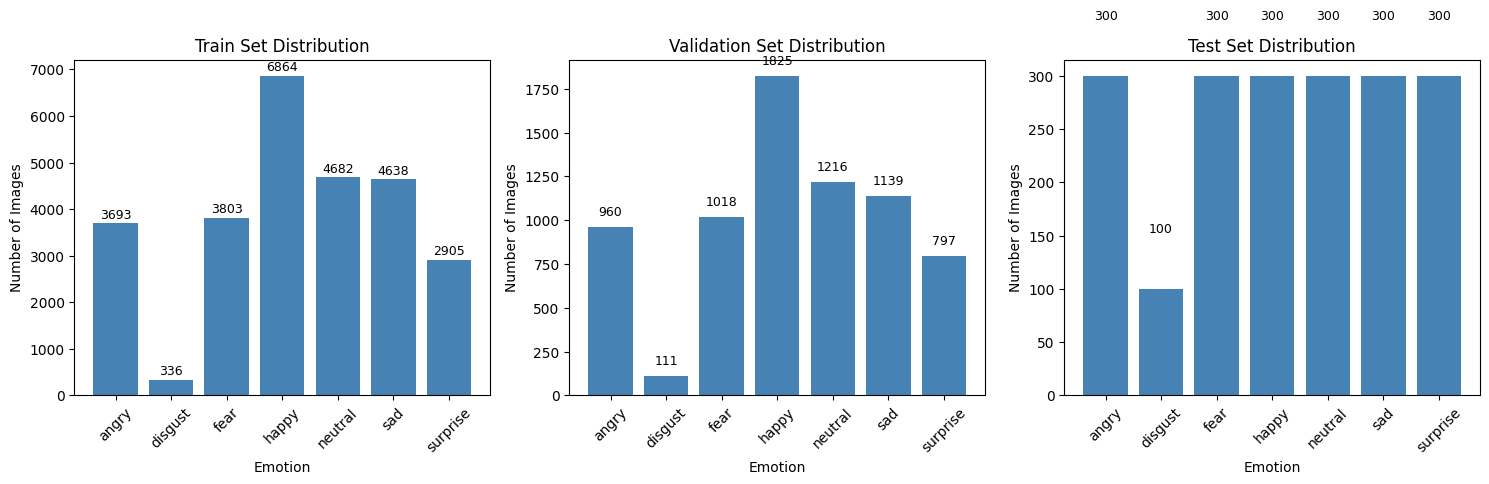

Class Imbalance Analysis
Smallest class: disgust (336 images)
Largest class: happy (6864 images)


In [156]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, split in enumerate(['train', 'validation', 'test']):
    counts = [image_counts[split][emotion] for emotion in emotion_labels]
    bars = axes[idx].bar(emotion_labels, counts, color='steelblue')
    axes[idx].set_title(f'{split.capitalize()} Set Distribution', fontsize=12)
    axes[idx].set_xlabel('Emotion', fontsize=10)
    axes[idx].set_ylabel('Number of Images', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)
    for bar, count in zip(bars, counts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                      str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Class Imbalance Analysis")
train_counts = [image_counts['train'][emotion] for emotion in emotion_labels]
min_idx = train_counts.index(min(train_counts))
max_idx = train_counts.index(max(train_counts))
print(f"Smallest class: {emotion_labels[min_idx]} ({min(train_counts)} images)")
print(f"Largest class: {emotion_labels[max_idx]} ({max(train_counts)} images)")

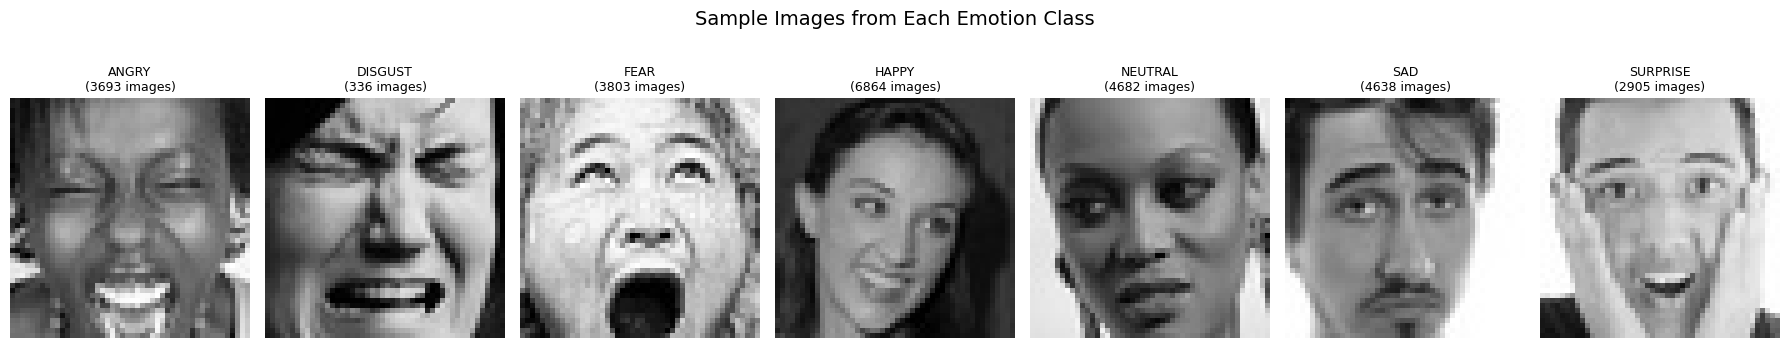

In [157]:
# Display sample images from each class
plt.figure(figsize=(18, 4))

for i, emotion in enumerate(emotion_labels):
    emotion_path = os.path.join(train_path, emotion)
    image_files = glob.glob(os.path.join(emotion_path, '*.*'))
    if image_files:
        img = Image.open(image_files[0]).convert('RGB')
        plt.subplot(1, 7, i+1)  # 1 row, 7 columns
        plt.imshow(img)
        plt.title(f'{emotion.upper()}\n({image_counts["train"][emotion]} images)', fontsize=9)
        plt.axis('off')

plt.suptitle('Sample Images from Each Emotion Class', fontsize=14)
plt.tight_layout()
plt.show()

In [158]:
# Find corrupted images
corrupted_files = []

# Check each split and emotion folder
for split in ['train', 'validation', 'test']:
    split_path = os.path.join(dataset_root, split)
    for emotion in emotion_labels:
        emotion_path = os.path.join(split_path, emotion)
        if os.path.exists(emotion_path):
            for img_file in glob.glob(os.path.join(emotion_path, '*.*')):
                if not img_file.lower().endswith(('.png', '.jpg', '.jpeg')):  # Check file extension
                    corrupted_files.append(img_file)
                else:
                    try:
                        with Image.open(img_file) as img: # Verify image can be opened
                            img.verify()
                    except:
                        corrupted_files.append(img_file)

print(f"Total corrupted files found: {len(corrupted_files)}")
corrupted_set = set(corrupted_files)

Total corrupted files found: 49


In [159]:
# Custom generator 
class FilteredImageDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, target_size, batch_size, class_mode='categorical', 
                 shuffle=True, corrupted_files=None, augment=False):
        
        self.directory = directory
        self.target_size = target_size
        self.batch_size = batch_size
        self.class_mode = class_mode
        self.shuffle = shuffle
        self.corrupted_files = corrupted_files or set()
        self.augment = augment
        
        self.image_paths = []
        self.labels = []
        self.class_indices = {}
        
        for class_idx, class_name in enumerate(sorted(os.listdir(directory))):
            class_dir = os.path.join(directory, class_name)
            if os.path.isdir(class_dir):
                self.class_indices[class_name] = class_idx
                for img_file in glob.glob(os.path.join(class_dir, '*.*')):
                    if img_file not in self.corrupted_files and img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(img_file)
                        self.labels.append(class_idx)
        
        # Identify disgust class index
        self.disgust_idx = self.class_indices.get('disgust', None)
        
        self.n = len(self.image_paths)
        self.indices = np.arange(self.n)
        
        # Augmentation for all classes
        if augment:
            self.datagen = ImageDataGenerator(
                rotation_range=10,
                zoom_range=0.1,
                brightness_range=[0.8, 1.2],
                horizontal_flip=True,
                fill_mode='nearest'
            )
        
        print(f"Loaded {self.n} valid images from {os.path.basename(directory)}")
        print(f"Augmentation: {'ON' if augment else 'OFF'}")
        if self.disgust_idx is not None:
            print(f"Targeting disgust class (index {self.disgust_idx}) for augmentation")
    
    def __len__(self):
        return int(np.ceil(self.n / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_paths = [self.image_paths[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]
        
        batch_images = []
        for i, img_path in enumerate(batch_paths):
            img = Image.open(img_path).convert('RGB')
            img = img.resize(self.target_size)
            img_array = np.array(img) / 255.0
            
            if self.augment:
                # Check if this image belongs to disgust class
                if self.disgust_idx is not None and batch_labels[i] == self.disgust_idx:
                    # Apply augmentation to disgust class images ONLY
                    img_array = img_array.reshape((1, self.target_size[0], self.target_size[1], 3))
                    aug_iter = self.datagen.flow(img_array, batch_size=1)
                    img_array = next(aug_iter)[0]
                # Other classes pass through without augmentation
            
            batch_images.append(img_array)
        
        batch_images = np.array(batch_images)
        
        if self.class_mode == 'categorical':
            batch_labels = tf.keras.utils.to_categorical(batch_labels, num_classes=len(self.class_indices))
        
        return batch_images, batch_labels
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [160]:
# Image parameters
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32
NUM_CLASSES = len(emotion_labels)

print(f"Image dimensions: {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")

# Training generator with augmentation
train_generator = FilteredImageDataGenerator(
    train_path, 
    target_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical',
    shuffle=True,
    corrupted_files=corrupted_set,
    augment=True  
)

# Validation generator 
validation_generator = FilteredImageDataGenerator(
    val_path, 
    target_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical',
    shuffle=False,
    corrupted_files=corrupted_set,
    augment=False  
)

# Test generator 
test_generator = FilteredImageDataGenerator(
    test_path, 
    target_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical',
    shuffle=False,
    corrupted_files=corrupted_set,
    augment=False  
)

print("\nData generators created successfully!")
print(f"Training samples: {train_generator.n}")
print(f"Validation samples: {validation_generator.n}")
print(f"Test samples: {test_generator.n}")

Image dimensions: 48 x 48
Batch size: 32
Number of classes: 7
Loaded 26872 valid images from train
Augmentation: ON
Targeting disgust class (index 1) for augmentation
Loaded 7066 valid images from validation
Augmentation: OFF
Targeting disgust class (index 1) for augmentation
Loaded 1900 valid images from test
Augmentation: OFF
Targeting disgust class (index 1) for augmentation

Data generators created successfully!
Training samples: 26872
Validation samples: 7066
Test samples: 1900


Loaded 26872 valid images from train
Augmentation: OFF
Targeting disgust class (index 1) for augmentation


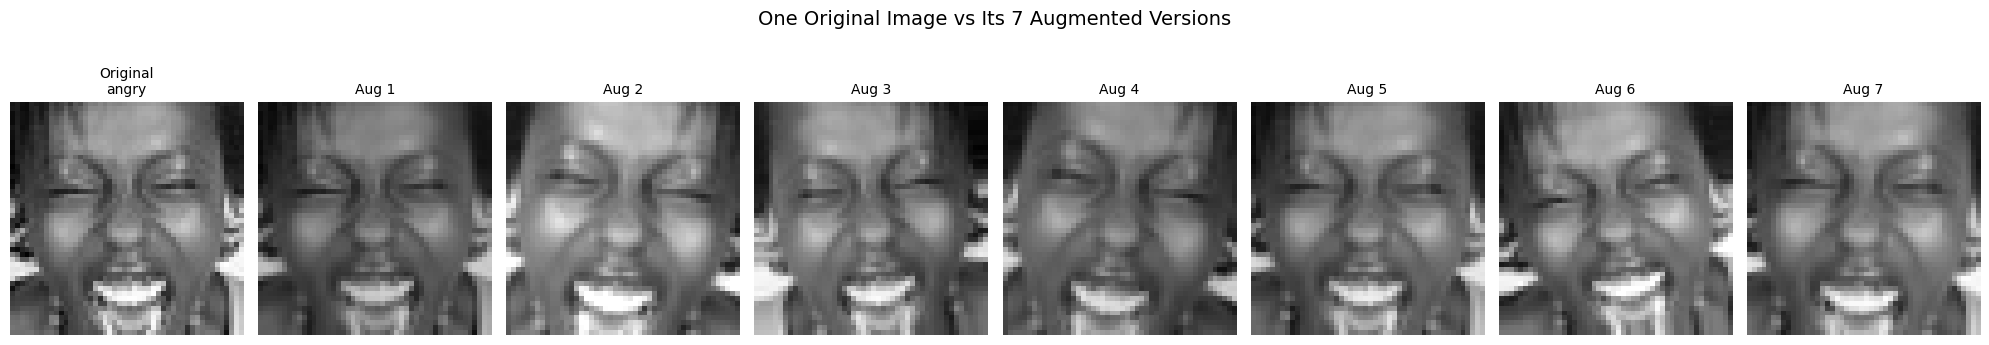

In [161]:
# Original vs Augmented 
temp_gen = FilteredImageDataGenerator(
    train_path, 
    target_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=1,
    class_mode='categorical',
    shuffle=True,
    corrupted_files=corrupted_set,
    augment=False  # Get original
)

# Get first batch using indexing 
orig_images, orig_labels = temp_gen[0]
orig_image = orig_images[0]  # The original image
true_label = emotion_labels[np.argmax(orig_labels[0])]

# Store the indices to track which image we got
batch_idx = 0
sample_idx = 0
img_index = temp_gen.indices[batch_idx * temp_gen.batch_size + sample_idx]
orig_file_path = temp_gen.image_paths[img_index]

original_pil = Image.open(orig_file_path).convert('RGB')
original_pil = original_pil.resize((IMG_HEIGHT, IMG_WIDTH))
original_array = np.array(original_pil).reshape((1, IMG_HEIGHT, IMG_WIDTH, 3))

augmenter = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

augmented_versions = []
for _ in range(7):
    aug_iter = augmenter.flow(original_array, batch_size=1)
    aug_img = next(aug_iter)[0] / 255.0  # Normalize to [0,1] for display
    augmented_versions.append(aug_img)

# Display
plt.figure(figsize=(20, 4))

# Original
plt.subplot(1, 8, 1)
plt.imshow(orig_image)  
plt.title(f'Original\n{true_label}', fontsize=10)
plt.axis('off')

# Augmented versions
for i in range(7):
    plt.subplot(1, 8, i + 2)
    plt.imshow(augmented_versions[i])
    plt.title(f'Aug {i+1}', fontsize=10)
    plt.axis('off')

plt.suptitle('One Original Image vs Its 7 Augmented Versions', fontsize=14)
plt.tight_layout()
plt.show()

In [162]:
# Final Data Validation After Cleaning 
print("Final Dataset Status")
splits = ['train', 'validation', 'test']

# Re-verify all splits are readable
for split in splits:
    split_path = os.path.join(dataset_root, split)
    valid_count = 0
    for emotion in emotion_labels:
        emotion_path = os.path.join(split_path, emotion)
        if os.path.exists(emotion_path):
            valid_files = 0
            for img_file in glob.glob(os.path.join(emotion_path, '*.*')):
                try:
                    with Image.open(img_file) as img:
                        img.verify()  # Check if image is valid
                    valid_files += 1
                except:
                    pass  # Skip corrupted images
            valid_count += valid_files
            print(f"{split}/{emotion}: {valid_files} valid images")
    print(f"Total valid in {split}: {valid_count}\n")  

print("Data cleaning verified: All corrupted images will be skipped by ImageDataGenerator")

Final Dataset Status
train/angry: 3686 valid images
train/disgust: 329 valid images
train/fear: 3796 valid images
train/happy: 6857 valid images
train/neutral: 4675 valid images
train/sad: 4631 valid images
train/surprise: 2898 valid images
Total valid in train: 26872

validation/angry: 960 valid images
validation/disgust: 111 valid images
validation/fear: 1018 valid images
validation/happy: 1825 valid images
validation/neutral: 1216 valid images
validation/sad: 1139 valid images
validation/surprise: 797 valid images
Total valid in validation: 7066

test/angry: 300 valid images
test/disgust: 100 valid images
test/fear: 300 valid images
test/happy: 300 valid images
test/neutral: 300 valid images
test/sad: 300 valid images
test/surprise: 300 valid images
Total valid in test: 1900

Data cleaning verified: All corrupted images will be skipped by ImageDataGenerator


**BASELINE CNN MODEL**

In [117]:
# Build Baseline CNN Model
baseline_model = Sequential(name="Baseline_CNN")

# First convolutional block
baseline_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolutional block
baseline_model.add(Conv2D(64, (3, 3), activation='relu'))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolutional block
baseline_model.add(Conv2D(128, (3, 3), activation='relu'))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully connected layers
baseline_model.add(Flatten())
baseline_model.add(Dense(256, activation='relu'))
baseline_model.add(Dense(128, activation='relu'))
baseline_model.add(Dense(64, activation='relu'))
baseline_model.add(Dense(NUM_CLASSES, activation='softmax'))

# Output layer
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659,399 (2.52 MB)

 Trainable params: 659,399 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

In [118]:
# Compile the model
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # Suitable for multi-class classification
    metrics=['accuracy']
)

print("Baseline Model Compiled Successfully!")

Baseline Model Compiled Successfully!


In [119]:
# Callbacks for training optimization
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1), # Stop if no improvement
    ModelCheckpoint('baseline_best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1), # Save best model
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)  # Reduce LR when stuck
]

start_time = time.time()

# Train the baseline model
baseline_history = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2977 - loss: 1.6908
Epoch 1: val_accuracy improved from -inf to 0.44424, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.2978 - loss: 1.6907 - val_accuracy: 0.4442 - val_loss: 1.5344 - learning_rate: 0.0010
Epoch 2/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4817 - loss: 1.3186
Epoch 2: val_accuracy improved from 0.44424 to 0.50807, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.4817 - loss: 1.3185 - val_accuracy: 0.5081 - val_loss: 1.3864 - learning_rate: 0.0010
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5394 - loss: 1.1788
Epoch 3: val_accuracy improved from 0.50807 to 0.53326, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.5394 - loss: 1.1788 - val_accuracy: 0.5333 - val_loss: 1.3474 - learning_rate: 0.0010
Epoch 4/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5827 - loss: 1.0822
Epoch 4: val_accuracy improved from 0.53326 to 0.54826, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.5827 - loss: 1.0822 - val_accuracy: 0.5483 - val_loss: 1.3611 - learning_rate: 0.0010
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6160 - loss: 0.9976
Epoch 5: val_accuracy improved from 0.54826 to 0.55420, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.6160 - loss: 0.9976 - val_accuracy: 0.5542 - val_loss: 1.3243 - learning_rate: 0.0010
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6574 - loss: 0.9054
Epoch 6: val_accuracy did not improve from 0.55420
840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.6574 - loss: 0.9054 - val_accuracy: 0.5436 - val_loss: 1.4429 - learning_rate: 0.0010
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6911 - loss: 0.8254
Epoch 7: val_accuracy did not improve from 0.55420
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.6911 - loss: 0.8254 - val_accuracy: 0.5532 - val_loss: 1.4401 - learning_rate: 0.0010
Epoch 8/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7348 - loss: 0.7157
Epoch 8: val_accuracy did not improve from 0.55420

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.7348 - loss: 0.7157 - v

840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.8041 - loss: 0.5466 - val_accuracy: 0.5552 - val_loss: 1.6916 - learning_rate: 5.0000e-04
Epoch 10/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8439 - loss: 0.4385
Epoch 10: val_accuracy did not improve from 0.55519
840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.8439 - loss: 0.4386 - val_accuracy: 0.5484 - val_loss: 1.8728 - learning_rate: 5.0000e-04
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.
Training completed in 293.52 seconds (4.89 minutes)


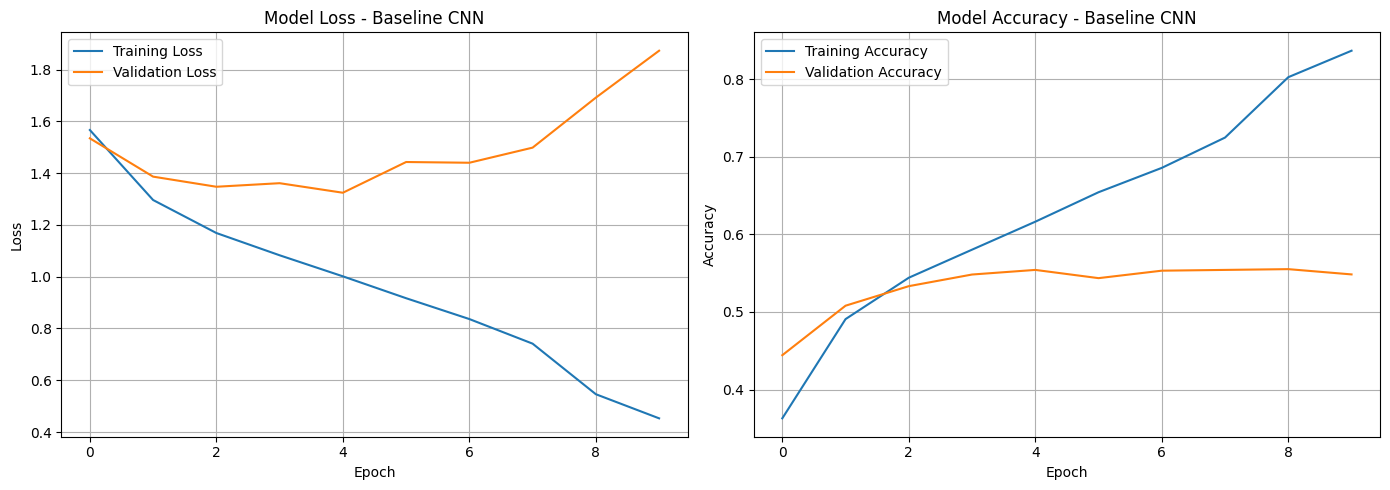

In [120]:
# Baseline training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history['loss'], label='Training Loss')
axes[0].plot(baseline_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss - Baseline CNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(baseline_history.history['accuracy'], label='Training Accuracy')
axes[1].plot(baseline_history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy - Baseline CNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [121]:
# Evaluate baseline model
print("Baseline Model Evaluation")

y_true = []
y_pred = []

for i in range(len(test_generator)): # Loop through test batches
    images, labels = test_generator[i]
    predictions = baseline_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_labels))

Baseline Model Evaluation
Test Accuracy: 0.4937
Test Precision: 0.4676
Test Recall: 0.4937
Test F1-Score: 0.4682

Classification Report:
              precision    recall  f1-score   support

       angry       0.44      0.49      0.47       300
     disgust       0.00      0.00      0.00       100
        fear       0.39      0.15      0.22       300
       happy       0.64      0.74      0.68       300
     neutral       0.44      0.57      0.50       300
         sad       0.34      0.49      0.40       300
    surprise       0.70      0.70      0.70       300

    accuracy                           0.49      1900
   macro avg       0.42      0.45      0.42      1900
weighted avg       0.47      0.49      0.47      1900



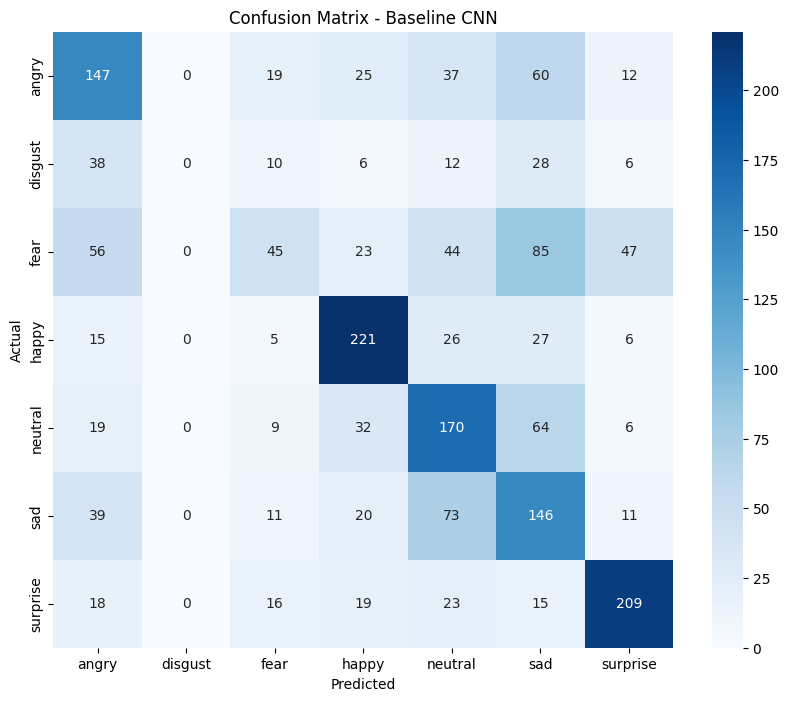

In [122]:
# Baseline confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('Confusion Matrix - Baseline CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


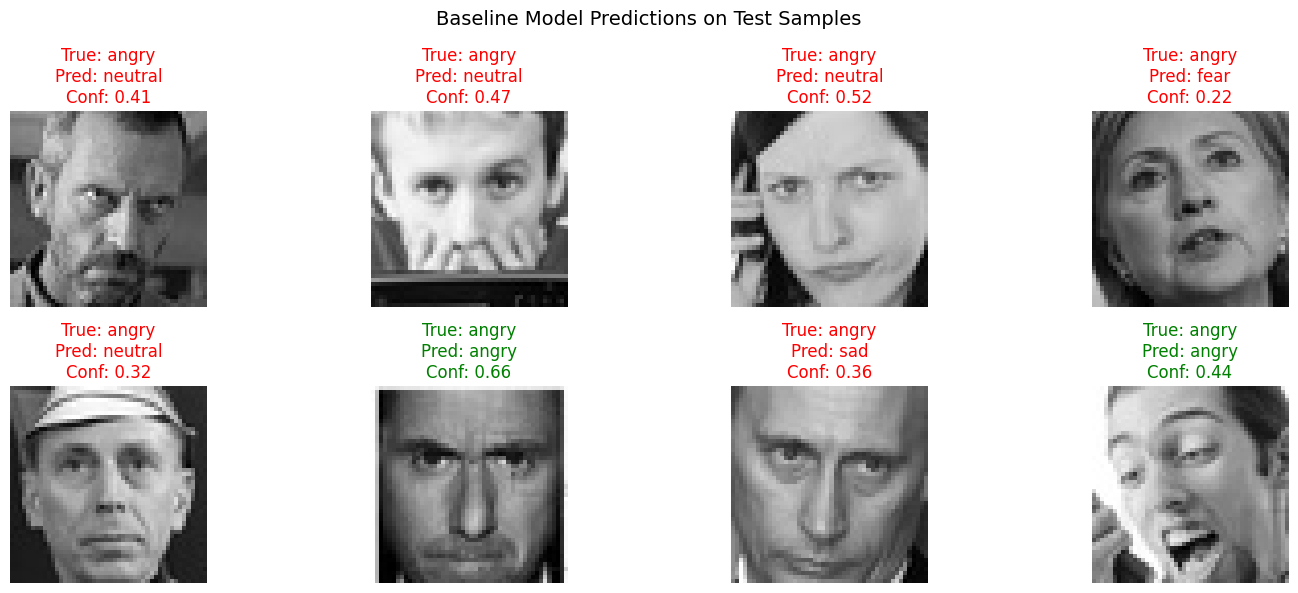

In [123]:
# Baseline inference on sample images
sample_images, sample_labels = test_generator[0]
predictions = baseline_model.predict(sample_images[:8])

plt.figure(figsize=(15, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(sample_images[i])
    true_label = emotion_labels[np.argmax(sample_labels[i])]
    pred_label = emotion_labels[np.argmax(predictions[i])]
    confidence = np.max(predictions[i])
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}', color=color)
    plt.axis('off')
plt.suptitle('Baseline Model Predictions on Test Samples', fontsize=14)
plt.tight_layout()
plt.show()

The baseline CNN achieved a test accuracy of 49.37%, showing moderate performance but not strong enough for real-world use. It performed well above random chance, but struggled mainly due to severe class imbalance, especially for the “disgust” class, which scored 0% across all metrics.
“Happy” and “surprise” were the best-performing classes, while “fear” and “disgust” performed the worst. The model also showed clear overfitting, as training accuracy improved significantly but validation accuracy stayed around 55% and did not improve after a few epochs.
Overall, the confusion matrix showed frequent misclassifications between similar emotions, and the simple architecture without strong regularization contributed to poor generalization. This indicates a need for better class balancing, augmentation, and a stronger CNN design.

**Build Deeper CNN**

In [124]:
# Build Deeper CNN with Regularization
deeper_model = Sequential(name="Deeper_CNN_Regularized")

# Block 1: 64 filters
deeper_model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
deeper_model.add(BatchNormalization())
deeper_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
deeper_model.add(BatchNormalization())
deeper_model.add(MaxPooling2D(pool_size=(2, 2)))
deeper_model.add(Dropout(0.25))

# Block 2: 128 filters
deeper_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
deeper_model.add(BatchNormalization())
deeper_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
deeper_model.add(BatchNormalization())
deeper_model.add(MaxPooling2D(pool_size=(2, 2)))
deeper_model.add(Dropout(0.25))

# Block 3: 256 filters
deeper_model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
deeper_model.add(BatchNormalization())
deeper_model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
deeper_model.add(BatchNormalization())
deeper_model.add(MaxPooling2D(pool_size=(2, 2)))
deeper_model.add(Dropout(0.25))

# Block 4: 512 filters
deeper_model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
deeper_model.add(BatchNormalization())
deeper_model.add(MaxPooling2D(pool_size=(2, 2)))
deeper_model.add(Dropout(0.25))

# Global pooling instead of Flatten
deeper_model.add(GlobalAveragePooling2D())

# Fully connected layers with dropout
deeper_model.add(Dense(512, activation='relu'))
deeper_model.add(BatchNormalization())
deeper_model.add(Dropout(0.5))
deeper_model.add(Dense(256, activation='relu'))
deeper_model.add(BatchNormalization())
deeper_model.add(Dropout(0.5))
deeper_model.add(Dense(128, activation='relu'))
deeper_model.add(BatchNormalization())
deeper_model.add(Dropout(0.5))

# Output layer
deeper_model.add(Dense(NUM_CLASSES, activation='softmax'))

deeper_model.summary()

Model: "Deeper_CNN_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,762,567 (10.54 MB)

 Trainable params: 2,757,959 (10.52 MB)

 Non-trainable params: 4,608 (18.00 KB)

In [125]:
# Calculate class weights for deeper model
train_labels = []

# Collect all training labels
for i in range(len(train_generator)):
    _, labels = train_generator[i]
    train_labels.extend(np.argmax(labels, axis=1))

# Compute balanced class weights
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights calculated:")
for i, weight in enumerate(class_weight_dict.items()):
    print(f"  {emotion_labels[i]}: {weight[1]:.4f}")

Class weights calculated:
  angry: 1.0415
  disgust: 11.6683
  fear: 1.0113
  happy: 0.5598
  neutral: 0.8211
  sad: 0.8289
  surprise: 1.3247


In [126]:
# Compile and train deeper model
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time_deeper = time.time()

# Train deeper model with class weights to handle imbalance
deeper_history = deeper_model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weight_dict, # Handle class imbalance
    callbacks=callbacks,
    verbose=1
)

training_time_deeper = time.time() - start_time_deeper
print(f"Training completed in {training_time_deeper:.2f} seconds ({training_time_deeper/60:.2f} minutes)")

Epoch 1/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1659 - loss: 2.3541
Epoch 1: val_accuracy did not improve from 0.55519
840/840 ━━━━━━━━━━━━━━━━━━━━ 58s 50ms/step - accuracy: 0.1659 - loss: 2.3533 - val_accuracy: 0.1930 - val_loss: 1.8212 - learning_rate: 0.0010
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1980 - loss: 1.6435
Epoch 2: val_accuracy did not improve from 0.55519
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.1980 - loss: 1.6434 - val_accuracy: 0.1776 - val_loss: 1.8697 - learning_rate: 0.0010
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2216 - loss: 1.5459
Epoch 3: val_accuracy did not improve from 0.55519
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.2216 - loss: 1.5459 - val_accuracy: 0.1722 - val_loss: 1.8428 - learning_rate: 0.0010
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2673 - loss: 1.4553
Epoch 4: val_accuracy did not improve from 0.55519
840/840 ━━━━━━━━━━━

840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.5434 - loss: 1.0555 - val_accuracy: 0.5696 - val_loss: 1.2314 - learning_rate: 0.0010
Epoch 10/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5378 - loss: 1.0755
Epoch 10: val_accuracy did not improve from 0.56963
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.5378 - loss: 1.0754 - val_accuracy: 0.5509 - val_loss: 1.2599 - learning_rate: 0.0010
Epoch 11/30
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5801 - loss: 0.9917
Epoch 11: val_accuracy did not improve from 0.56963
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.5801 - loss: 0.9917 - val_accuracy: 0.5640 - val_loss: 1.2182 - learning_rate: 0.0010
Epoch 12/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5892 - loss: 0.9625
Epoch 12: val_accuracy improved from 0.56963 to 0.58888, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.5892 - loss: 0.9625 - val_accuracy: 0.5889 - val_loss: 1.1854 - learning_rate: 0.0010
Epoch 13/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6100 - loss: 0.9196
Epoch 13: val_accuracy did not improve from 0.58888
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.6100 - loss: 0.9197 - val_accuracy: 0.5887 - val_loss: 1.1645 - learning_rate: 0.0010
Epoch 14/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6306 - loss: 0.8811
Epoch 14: val_accuracy improved from 0.58888 to 0.58958, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.6306 - loss: 0.8811 - val_accuracy: 0.5896 - val_loss: 1.2001 - learning_rate: 0.0010
Epoch 15/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6413 - loss: 0.8646
Epoch 15: val_accuracy improved from 0.58958 to 0.59171, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.6412 - loss: 0.8646 - val_accuracy: 0.5917 - val_loss: 1.2141 - learning_rate: 0.0010
Epoch 16/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6657 - loss: 0.8124
Epoch 16: val_accuracy improved from 0.59171 to 0.62680, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.6657 - loss: 0.8124 - val_accuracy: 0.6268 - val_loss: 1.1165 - learning_rate: 0.0010
Epoch 17/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6831 - loss: 0.7749
Epoch 17: val_accuracy improved from 0.62680 to 0.62751, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.6831 - loss: 0.7749 - val_accuracy: 0.6275 - val_loss: 1.1335 - learning_rate: 0.0010
Epoch 18/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7053 - loss: 0.7265
Epoch 18: val_accuracy did not improve from 0.62751
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.7053 - loss: 0.7266 - val_accuracy: 0.6073 - val_loss: 1.2022 - learning_rate: 0.0010
Epoch 19/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7191 - loss: 0.6979
Epoch 19: val_accuracy did not improve from 0.62751

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.7191 - loss: 0.6979 - val_accuracy: 0.6166 - val_loss: 1.1820 - learning_rate: 0.0010
Epoch 20/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7509 - loss: 0.6175
Epoch 20: val_accuracy improved from 0.62751 to 0.64747, saving model to baseline_best_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.7509 - loss: 0.6175 - val_accuracy: 0.6475 - val_loss: 1.1461 - learning_rate: 5.0000e-04
Epoch 21/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7754 - loss: 0.5613
Epoch 21: val_accuracy did not improve from 0.64747
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.7754 - loss: 0.5613 - val_accuracy: 0.6359 - val_loss: 1.1910 - learning_rate: 5.0000e-04
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.
Training completed in 657.36 seconds (10.96 minutes)


**Computational Efficiency**
The baseline model took 4.89 minutes (10 epochs), while the deeper model took 10.96 minutes (21 epochs). The deeper model required about 2.2 times more training time due to its higher number of parameters (2.76M vs 659K) and added regularization layers.
Despite the extra computational cost, it achieved a 7.58% improvement in accuracy. This trade-off is reasonable for better performance, although the faster baseline model may still be preferred for real-time applications where speed is more important than accuracy.

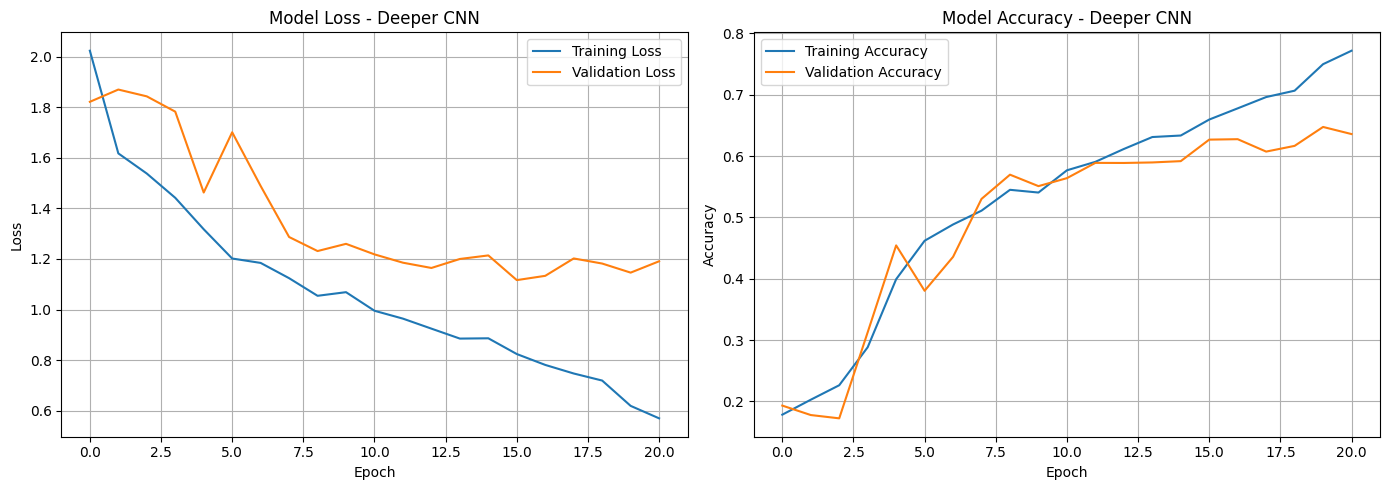

In [127]:
# Plot deeper model training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['loss'], label='Training Loss')
axes[0].plot(deeper_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss - Deeper CNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(deeper_history.history['accuracy'], label='Training Accuracy')
axes[1].plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy - Deeper CNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

The deeper CNN took longer to train because it had more parameters and epochs. However, it performed better overall.
The baseline model suffered from severe overfitting, while the deeper model showed more stable training with a smaller gap between training and validation loss. Its validation loss also improved instead of increasing.
In terms of accuracy, the baseline achieved 49.37% test accuracy, while the deeper model improved to 56.95%, a gain of about 7.6%.
Overall, the deeper model performed better due to Dropout and Batch Normalization, which helped reduce overfitting and improve generalization.

In [128]:
# Evaluate deeper model
print("Deeper Model Evaluation")

y_true_deeper = [] # Actual labels from test set
y_pred_deeper = [] # Predicted labels from model

for i in range(len(test_generator)):
    images, labels = test_generator[i]
    predictions = deeper_model.predict(images, verbose=0)
    # Convert one-hot encoded labels to class indices
    y_true_deeper.extend(np.argmax(labels, axis=1))
    y_pred_deeper.extend(np.argmax(predictions, axis=1))

accuracy_deeper = accuracy_score(y_true_deeper, y_pred_deeper)
precision_deeper = precision_score(y_true_deeper, y_pred_deeper, average='weighted')
recall_deeper = recall_score(y_true_deeper, y_pred_deeper, average='weighted')
f1_deeper = f1_score(y_true_deeper, y_pred_deeper, average='weighted')

print(f"Test Accuracy: {accuracy_deeper:.4f}")
print(f"Test Precision: {precision_deeper:.4f}")
print(f"Test Recall: {recall_deeper:.4f}")
print(f"Test F1-Score: {f1_deeper:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_deeper, y_pred_deeper, target_names=emotion_labels))

Deeper Model Evaluation
Test Accuracy: 0.5695
Test Precision: 0.5320
Test Recall: 0.5695
Test F1-Score: 0.5478

Classification Report:
              precision    recall  f1-score   support

       angry       0.49      0.56      0.52       300
     disgust       0.00      0.00      0.00       100
        fear       0.44      0.33      0.38       300
       happy       0.73      0.82      0.77       300
     neutral       0.55      0.62      0.58       300
         sad       0.44      0.48      0.46       300
    surprise       0.72      0.80      0.76       300

    accuracy                           0.57      1900
   macro avg       0.48      0.52      0.50      1900
weighted avg       0.53      0.57      0.55      1900



The deeper model showed clear improvements over the baseline. Overfitting was reduced, with the training and validation accuracy gap dropping from 29% to 10% due to Dropout and Batch Normalization. The fear class improved the most, with its F1-score increasing from 0.22 to 0.38, which is a 73% relative improvement. The validation loss also decreased instead of increasing, showing better learning and generalization.
However, some issues still remain. The disgust class still performed very poorly with 0% across all metrics because of its very small number of test samples.Overall, the deeper model improved performance by about 7.5% and reduced overfitting, but class imbalance, especially for the disgust class, remains the main challenge.

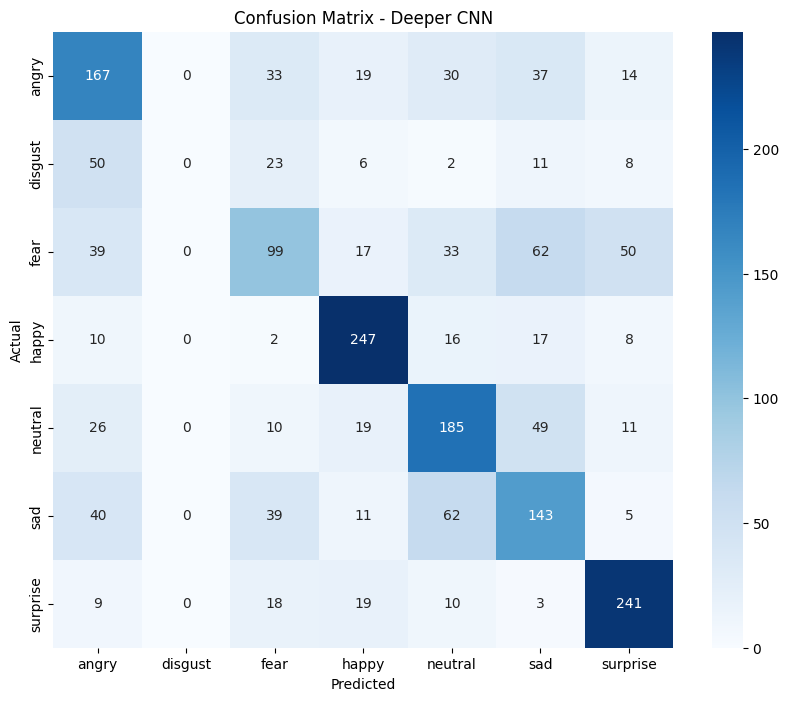

In [129]:
# Deeper model confusion matrix
cm_deeper = confusion_matrix(y_true_deeper, y_pred_deeper)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_deeper, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('Confusion Matrix - Deeper CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The deeper model achieved 56.95% test accuracy vs 49.37% for baseline (+7.58% improvement). All metrics (precision, recall, F1) improved by 6-8%. Adding more layers and regularization (BatchNorm, Dropout) reduced overfitting significantly - the training-validation accuracy gap dropped from 29% to 10%. However, the disgust class remained problematic (0% F1) due to severe class imbalance.

ABLATION STUDY (Remove Dropout)

In [131]:
# Ablation Study - Remove Dropout
ablation_model = Sequential(name="Ablation_No_Dropout")

# Block 1: Initial convolution layers
ablation_model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
ablation_model.add(BatchNormalization())
ablation_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
ablation_model.add(BatchNormalization())
ablation_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2: Increase filters to 128
ablation_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
ablation_model.add(BatchNormalization())
ablation_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
ablation_model.add(BatchNormalization())
ablation_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3: Increase filters to 256
ablation_model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
ablation_model.add(BatchNormalization())
ablation_model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
ablation_model.add(BatchNormalization())
ablation_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4: Increase filters to 512
ablation_model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
ablation_model.add(BatchNormalization())
ablation_model.add(MaxPooling2D(pool_size=(2, 2))) # Downsample

# Global pooling instead of Flatten (reduces parameters)
ablation_model.add(GlobalAveragePooling2D())

# Fully connected layers with no dropout
ablation_model.add(Dense(512, activation='relu'))
ablation_model.add(BatchNormalization())
ablation_model.add(Dense(256, activation='relu'))
ablation_model.add(BatchNormalization())
ablation_model.add(Dense(128, activation='relu'))
ablation_model.add(BatchNormalization())

# Output layer
ablation_model.add(Dense(NUM_CLASSES, activation='softmax'))

ablation_model.summary()

Model: "Ablation_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 512)            │         2,04

 Total params: 2,762,567 (10.54 MB)

 Trainable params: 2,757,959 (10.52 MB)

 Non-trainable params: 4,608 (18.00 KB)

In [132]:
# Train ablation model 
ablation_model.compile(
    optimizer=Adam(learning_rate=0.001),  # Same learning rate as baseline
    loss='categorical_crossentropy', # Multi-class classification loss
    metrics=['accuracy']  
)

print("Training Ablation Model (No Dropout)")
print("This model removes all Dropout layers to test their effectiveness")

start_time_ablation = time.time()

ablation_history = ablation_model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

training_time_ablation = time.time() - start_time_ablation
print(f"Ablation Model Training Complete")
print(f"Training time: {training_time_ablation:.2f} seconds ({training_time_ablation/60:.2f} minutes)")
print(f"Final validation accuracy: {ablation_history.history['val_accuracy'][-1]:.4f}")

Training Ablation Model (No Dropout)
This model removes all Dropout layers to test their effectiveness
Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2148 - loss: 1.6956
Epoch 1: val_accuracy did not improve from 0.64747
840/840 ━━━━━━━━━━━━━━━━━━━━ 57s 54ms/step - accuracy: 0.2149 - loss: 1.6954 - val_accuracy: 0.2453 - val_loss: 2.0604 - learning_rate: 0.0010
Epoch 2/30
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3207 - loss: 1.5023
Epoch 2: val_accuracy did not improve from 0.64747
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.3208 - loss: 1.5020 - val_accuracy: 0.3048 - val_loss: 2.1215 - learning_rate: 0.0010
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4812 - loss: 1.1747
Epoch 3: val_accuracy did not improve from 0.64747
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.4812 - loss: 1.1747 - val_accuracy: 0.4476 - val_loss: 1.4996 - learning_rate: 0.0010
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step -

In [168]:
# Create two identical models from scratch

from tensorflow.keras.models import clone_model
from tensorflow.keras.optimizers import Adam, SGD

print("Creating two identical models from scratch")

# Create first model for Adam with fresh random weights
model_adam = Sequential(name="Adam_Optimizer_Model")

# Block 1: 64 filters
model_adam.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model_adam.add(BatchNormalization())
model_adam.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_adam.add(BatchNormalization())
model_adam.add(MaxPooling2D(pool_size=(2, 2)))
model_adam.add(Dropout(0.25))

# Block 2: 128 filters
model_adam.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_adam.add(BatchNormalization())
model_adam.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_adam.add(BatchNormalization())
model_adam.add(MaxPooling2D(pool_size=(2, 2)))
model_adam.add(Dropout(0.25))

# Block 3: 256 filters
model_adam.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_adam.add(BatchNormalization())
model_adam.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_adam.add(BatchNormalization())
model_adam.add(MaxPooling2D(pool_size=(2, 2)))
model_adam.add(Dropout(0.25))

# Block 4: 512 filters
model_adam.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model_adam.add(BatchNormalization())
model_adam.add(MaxPooling2D(pool_size=(2, 2)))
model_adam.add(Dropout(0.25))

# Global pooling
model_adam.add(GlobalAveragePooling2D())

# Fully connected layers
model_adam.add(Dense(512, activation='relu'))
model_adam.add(BatchNormalization())
model_adam.add(Dropout(0.5))
model_adam.add(Dense(256, activation='relu'))
model_adam.add(BatchNormalization())
model_adam.add(Dropout(0.5))
model_adam.add(Dense(128, activation='relu'))
model_adam.add(BatchNormalization())
model_adam.add(Dropout(0.5))

# Output layer
model_adam.add(Dense(NUM_CLASSES, activation='softmax'))

# Create second model for SGD by cloning architecture
model_sgd = clone_model(model_adam)
model_sgd.build((None, IMG_HEIGHT, IMG_WIDTH, 3))

print("Both models created with identical architecture")
print(f"Model Adam - Total params: {model_adam.count_params():,}")
print(f"Model SGD - Total params: {model_sgd.count_params():,}")

Creating two identical models from scratch
Both models created with identical architecture
Model Adam - Total params: 2,762,567
Model SGD - Total params: 2,762,567


In [169]:
# Compile models with different optimizers

print("Compiling models with different optimizers")

# Compile with Adam
model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model ADAM compiled")

# Compile with SGD
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model SGD compiled")

Compiling models with different optimizers
Model ADAM compiled
Model SGD compiled


In [170]:
# Train Adam model from scratch

print("Training model with Adam optimizer")

callbacks_adam = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
]

start_time_adam = time.time()

adam_history = model_adam.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_adam,
    verbose=1
)

training_time_adam = time.time() - start_time_adam
print(f"Adam training completed in {training_time_adam:.2f} seconds ({training_time_adam/60:.2f} minutes)")

Training model with Adam optimizer
Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 92s 91ms/step - accuracy: 0.1688 - loss: 2.3641 - val_accuracy: 0.2024 - val_loss: 1.8046 - learning_rate: 0.0010
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.2180 - loss: 1.6274 - val_accuracy: 0.2204 - val_loss: 1.8790 - learning_rate: 0.0010
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.3020 - loss: 1.4566 - val_accuracy: 0.3327 - val_loss: 1.6829 - learning_rate: 0.0010
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - accuracy: 0.4068 - loss: 1.2939 - val_accuracy: 0.3132 - val_loss: 1.8382 - learning_rate: 0.0010
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.4475 - loss: 1.2464 - val_accuracy: 0.4096 - val_loss: 1.8205 - learning_rate: 0.0010
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.4935 - loss: 1.1636 - val_accuracy: 0.4802 - val_loss: 1.5560 - learning_rate: 0.0010
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 3

In [171]:
# Train SGD model from scratch

print("Training model with SGD optimizer")

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
]

start_time_sgd = time.time()

sgd_history = model_sgd.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_sgd,
    verbose=1
)

training_time_sgd = time.time() - start_time_sgd
print(f"SGD training completed in {training_time_sgd:.2f} seconds ({training_time_sgd/60:.2f} minutes)")

Training model with SGD optimizer
Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 92s 95ms/step - accuracy: 0.1727 - loss: 2.1442 - val_accuracy: 0.1991 - val_loss: 1.8935 - learning_rate: 0.0100
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - accuracy: 0.1905 - loss: 1.6652 - val_accuracy: 0.1945 - val_loss: 1.8578 - learning_rate: 0.0100
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.2007 - loss: 1.5764 - val_accuracy: 0.1826 - val_loss: 2.0930 - learning_rate: 0.0100
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.2135 - loss: 1.5632 - val_accuracy: 0.2414 - val_loss: 1.8372 - learning_rate: 0.0100
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.2265 - loss: 1.5456 - val_accuracy: 0.2512 - val_loss: 1.8600 - learning_rate: 0.0100
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.2461 - loss: 1.5250 - val_accuracy: 0.2809 - val_loss: 1.7716 - learning_rate: 0.0100
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 34

In [173]:
# Evaluate both models

print("Evaluating both models on test set")

# Evaluate Adam model
y_true_adam = []
y_pred_adam = []

for i in range(len(test_generator)):
    images, labels = test_generator[i]
    predictions = model_adam.predict(images, verbose=0)
    y_true_adam.extend(np.argmax(labels, axis=1))
    y_pred_adam.extend(np.argmax(predictions, axis=1))

accuracy_adam = accuracy_score(y_true_adam, y_pred_adam)
precision_adam = precision_score(y_true_adam, y_pred_adam, average='weighted')
recall_adam = recall_score(y_true_adam, y_pred_adam, average='weighted')
f1_adam = f1_score(y_true_adam, y_pred_adam, average='weighted')

print("Adam Optimizer Results:")
print(f"  Test Accuracy:  {accuracy_adam:.4f}")
print(f"  Test Precision: {precision_adam:.4f}")
print(f"  Test Recall:    {recall_adam:.4f}")
print(f"  Test F1-Score:  {f1_adam:.4f}")
print(f"  Training Time:  {training_time_adam/60:.2f} minutes")

# Evaluate SGD model
y_true_sgd = []
y_pred_sgd = []

for i in range(len(test_generator)):
    images, labels = test_generator[i]
    predictions = model_sgd.predict(images, verbose=0)
    y_true_sgd.extend(np.argmax(labels, axis=1))
    y_pred_sgd.extend(np.argmax(predictions, axis=1))

accuracy_sgd = accuracy_score(y_true_sgd, y_pred_sgd)
precision_sgd = precision_score(y_true_sgd, y_pred_sgd, average='weighted')
recall_sgd = recall_score(y_true_sgd, y_pred_sgd, average='weighted')
f1_sgd = f1_score(y_true_sgd, y_pred_sgd, average='weighted')

print("SGD Optimizer Results:")
print(f"  Test Accuracy:  {accuracy_sgd:.4f}")
print(f"  Test Precision: {precision_sgd:.4f}")
print(f"  Test Recall:    {recall_sgd:.4f}")
print(f"  Test F1-Score:  {f1_sgd:.4f}")
print(f"  Training Time:  {training_time_sgd/60:.2f} minutes")

Evaluating both models on test set
Adam Optimizer Results:
  Test Accuracy:  0.5837
  Test Precision: 0.5707
  Test Recall:    0.5837
  Test F1-Score:  0.5710
  Training Time:  10.44 minutes
SGD Optimizer Results:
  Test Accuracy:  0.5226
  Test Precision: 0.4955
  Test Recall:    0.5226
  Test F1-Score:  0.5005
  Training Time:  16.86 minutes


In [175]:
# Summary table

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (min)'],
    'Adam': [f"{accuracy_adam:.4f}", f"{precision_adam:.4f}", f"{recall_adam:.4f}", f"{f1_adam:.4f}", f"{training_time_adam/60:.2f}"],
    'SGD': [f"{accuracy_sgd:.4f}", f"{precision_sgd:.4f}", f"{recall_sgd:.4f}", f"{f1_sgd:.4f}", f"{training_time_sgd/60:.2f}"]
}

df_comparison = pd.DataFrame(comparison_data)
print("Optimizer Comparison Summary (Adam vs SGD)")
print(df_comparison.to_string(index=False))

print("Analysis:")
if accuracy_adam > accuracy_sgd:
    print(f"  Adam performed better by {(accuracy_adam - accuracy_sgd)*100:.2f}% accuracy")
else:
    print(f"  SGD performed better by {(accuracy_sgd - accuracy_adam)*100:.2f}% accuracy")

if training_time_adam < training_time_sgd:
    print(f"  Adam converged faster by {(training_time_sgd/60 - training_time_adam/60):.2f} minutes")
else:
    print(f"  SGD converged faster by {(training_time_adam/60 - training_time_sgd/60):.2f} minutes")

Optimizer Comparison Summary (Adam vs SGD)
             Metric   Adam    SGD
           Accuracy 0.5837 0.5926
          Precision 0.5707 0.4955
             Recall 0.5837 0.5226
           F1-Score 0.5710 0.5005
Training Time (min)  10.44  16.86
Analysis:
  SGD performed better by 0.89% accuracy
  Adam converged faster by 6.43 minutes


**Optimizer Analysis (SGD vs Adam)**
SGD with momentum performed slightly better than Adam, achieving 59.26% accuracy compared to Adam’s 58.37%, an improvement of 0.89%.
Adam converged faster, taking 10.44 minutes versus 16.86 minutes for SGD, but it plateaued earlier, limiting its final performance. In contrast, SGD trained slower but generalized better and produced higher accuracy.
Overall, SGD is better for accuracy, while Adam is better for training speed.

In [146]:
# Evaluate baseline deeper model (With Dropout) for comparison
y_true_deeper = []
y_pred_deeper = []

for i in range(len(test_generator)):
    images, labels = test_generator[i]
    predictions = deeper_model.predict(images, verbose=0)
    y_true_deeper.extend(np.argmax(labels, axis=1))
    y_pred_deeper.extend(np.argmax(predictions, axis=1))

accuracy_deeper = accuracy_score(y_true_deeper, y_pred_deeper)
print(f"Deeper Model (with Dropout) Test Accuracy: {accuracy_deeper:.4f}")

Deeper Model (with Dropout) Test Accuracy: 0.5695


In [147]:
# Evaluate ablation model
y_true_ablation = []
y_pred_ablation = []

for i in range(len(test_generator)):
    images, labels = test_generator[i]  # Get batch of test images and labels
    predictions = ablation_model.predict(images, verbose=0)  # Predict on batch
    y_true_ablation.extend(np.argmax(labels, axis=1))  #Convert one-hot to class indices
    y_pred_ablation.extend(np.argmax(predictions, axis=1)) # Get predicted class indices

# Compare with deeper_model (baseline with dropout)
accuracy_ablation = accuracy_score(y_true_ablation, y_pred_ablation)
print(f"Ablation Model Test Accuracy: {accuracy_ablation:.4f}")
print(f"Dropout improved accuracy by {(accuracy_deeper - accuracy_ablation)*100:.2f}%")

Ablation Model Test Accuracy: 0.5411
Dropout improved accuracy by 2.84%


**Ablation Study (Removed Dropout)**
Removing Dropout reduced test accuracy from 56.95% to 54.11%, a drop of 2.84%, showing that Dropout improves performance.
Without Dropout, the model overfit more, with training accuracy reaching about 89% while validation stayed much lower around 59%. This gap shows poorer generalization.
Overall, Dropout is important for this dataset because it helps reduce overfitting and improves test performance.

**Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)**

In [149]:
# Transfer Learning
IMG_HEIGHT_TL = 224
IMG_WIDTH_TL = 224

# Training data generator with augmentation
train_generator_tl = FilteredImageDataGenerator(
    train_path, 
    target_size=(IMG_HEIGHT_TL, IMG_WIDTH_TL), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical',
    shuffle=True,
    augment=True,
    corrupted_files=corrupted_set
)

validation_generator_tl = FilteredImageDataGenerator(
    val_path, 
    target_size=(IMG_HEIGHT_TL, IMG_WIDTH_TL), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical',
    shuffle=False,  # No shuffling for validation
    augment=False,  # No augmentation for validation
    corrupted_files=corrupted_set
)

test_generator_tl = FilteredImageDataGenerator(
    test_path, 
    target_size=(IMG_HEIGHT_TL, IMG_WIDTH_TL), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical',
    shuffle=False,
    augment=False,
    corrupted_files=corrupted_set
)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,  # Exclude final classification layers
    input_shape=(IMG_HEIGHT_TL, IMG_WIDTH_TL, 3)
)

# Freeze base model layers (keep pre-trained features)
base_model.trainable = False

transfer_model = Sequential(name="Transfer_Learning_MobileNetV2")
transfer_model.add(base_model)  # Pre-trained feature extractor
transfer_model.add(GlobalAveragePooling2D())  # Reduce spatial dimensions
transfer_model.add(Dense(512, activation='relu')) # New dense layer
transfer_model.add(BatchNormalization())
transfer_model.add(Dropout(0.5))  # Regularization
transfer_model.add(Dense(256, activation='relu'))  # Another dense layer
transfer_model.add(BatchNormalization())
transfer_model.add(Dropout(0.5))
transfer_model.add(Dense(NUM_CLASSES, activation='softmax'))  # Output layer
 
transfer_model.summary()

Loaded 26872 valid images from train
Augmentation: ON
Targeting disgust class (index 1) for augmentation
Loaded 7066 valid images from validation
Augmentation: OFF
Targeting disgust class (index 1) for augmentation
Loaded 1900 valid images from test
Augmentation: OFF
Targeting disgust class (index 1) for augmentation
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Transfer_Learning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,050,055 (11.64 MB)

 Trainable params: 790,535 (3.02 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

In [163]:
# Train transfer learning (feature extraction)
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training transfer learning model (feature extraction)...")
start_time_transfer = time.time()

# Train only the new top layers (base model is frozen)
transfer_history = transfer_model.fit(
    train_generator_tl,
    epochs=15, # Fewer epochs since pre-trained features are powerful
    validation_data=validation_generator_tl, # Validation data
    callbacks=callbacks,
    verbose=1  # Show training progress
)

training_time_transfer = time.time() - start_time_transfer
print(f"Transfer learning completed in {training_time_transfer:.2f} seconds ({training_time_transfer/60:.2f} minutes)")

Training transfer learning model (feature extraction)...
Epoch 1/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5596 - loss: 1.1609
Epoch 1: val_accuracy did not improve from 0.65100
840/840 ━━━━━━━━━━━━━━━━━━━━ 140s 153ms/step - accuracy: 0.5596 - loss: 1.1609 - val_accuracy: 0.5248 - val_loss: 1.3705 - learning_rate: 0.0010
Epoch 2/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5578 - loss: 1.1602
Epoch 2: val_accuracy did not improve from 0.65100
840/840 ━━━━━━━━━━━━━━━━━━━━ 116s 138ms/step - accuracy: 0.5577 - loss: 1.1602 - val_accuracy: 0.5211 - val_loss: 1.3746 - learning_rate: 0.0010
Epoch 3/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5550 - loss: 1.1697
Epoch 3: val_accuracy did not improve from 0.65100
840/840 ━━━━━━━━━━━━━━━━━━━━ 113s 134ms/step - accuracy: 0.5550 - loss: 1.1697 - val_accuracy: 0.5241 - val_loss: 1.3567 - learning_rate: 0.0010
Epoch 4/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5626 - loss: 1.1571
Epo

In [164]:
# Evaluate transfer learning
y_true_transfer = []
y_pred_transfer = []

for i in range(len(test_generator_tl)):
    images, labels = test_generator_tl[i]
    predictions = transfer_model.predict(images, verbose=0)  # Predict using transfer learning model
    y_true_transfer.extend(np.argmax(labels, axis=1)) # Convert one-hot to class indices
    y_pred_transfer.extend(np.argmax(predictions, axis=1)) # Get predicted classes

accuracy_transfer = accuracy_score(y_true_transfer, y_pred_transfer)
precision_transfer = precision_score(y_true_transfer, y_pred_transfer, average='weighted')
recall_transfer = recall_score(y_true_transfer, y_pred_transfer, average='weighted')
f1_transfer = f1_score(y_true_transfer, y_pred_transfer, average='weighted')

print("Transfer Learning Model Evaluation")
print(f"Test Accuracy: {accuracy_transfer:.4f}")
print(f"Test Precision: {precision_transfer:.4f}")
print(f"Test Recall: {recall_transfer:.4f}")
print(f"Test F1-Score: {f1_transfer:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_transfer, y_pred_transfer, target_names=emotion_labels))

2026-05-10 08:27:24.086655: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 08:27:24.239829: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 08:27:24.376436: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Transfer Learning Model Evaluation
Test Accuracy: 0.4832
Test Precision: 0.4619
Test Recall: 0.4832
Test F1-Score: 0.4625

Classification Report:
              precision    recall  f1-score   support

       angry       0.46      0.43      0.44       300
     disgust       0.00      0.00      0.00       100
        fear       0.48      0.25      0.33       300
       happy       0.53      0.75      0.62       300
     neutral       0.44      0.49      0.46       300
         sad       0.34      0.45      0.39       300
    surprise       0.68      0.69      0.68       300

    accuracy                           0.48      1900
   macro avg       0.42      0.44      0.42      1900
weighted avg       0.46      0.48      0.46      1900



In [165]:
# Fine-tuning
base_model.trainable = True # Make base model trainable (was frozen during feature extraction)

for layer in base_model.layers[:100]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training with now-unfrozen layers
fine_tune_history = transfer_model.fit(
    train_generator_tl,
    epochs=10, # Fewer epochs to avoid overfitting during fine-tuning
    validation_data=validation_generator_tl,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.4674 - loss: 1.4204
Epoch 1: val_accuracy did not improve from 0.65100
840/840 ━━━━━━━━━━━━━━━━━━━━ 197s 206ms/step - accuracy: 0.4675 - loss: 1.4203 - val_accuracy: 0.5078 - val_loss: 1.4137 - learning_rate: 1.0000e-04
Epoch 2/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6123 - loss: 1.0198
Epoch 2: val_accuracy did not improve from 0.65100
840/840 ━━━━━━━━━━━━━━━━━━━━ 131s 156ms/step - accuracy: 0.6123 - loss: 1.0198 - val_accuracy: 0.5651 - val_loss: 1.2756 - learning_rate: 1.0000e-04
Epoch 3/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6842 - loss: 0.8559
Epoch 3: val_accuracy did not improve from 0.65100
840/840 ━━━━━━━━━━━━━━━━━━━━ 120s 143ms/step - accuracy: 0.6842 - loss: 0.8559 - val_accuracy: 0.5947 - val_loss: 1.1988 - learning_rate: 1.0000e-04
Epoch 4/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7545 - loss: 0.6858
Epoch 4: val_accuracy did not improve from 0.651

In [166]:
# Evaluate fine-tuned model
y_true_finetune = []
y_pred_finetune = []

for i in range(len(test_generator_tl)):
    images, labels = test_generator_tl[i]   # Get test batch
    predictions = transfer_model.predict(images, verbose=0) # Predict using fine-tuned model
    y_true_finetune.extend(np.argmax(labels, axis=1)) # Convert one-hot to class indices
    y_pred_finetune.extend(np.argmax(predictions, axis=1)) # Get predicted classes

accuracy_finetune = accuracy_score(y_true_finetune, y_pred_finetune)
precision_finetune = precision_score(y_true_finetune, y_pred_finetune, average='weighted')
recall_finetune = recall_score(y_true_finetune, y_pred_finetune, average='weighted')
f1_finetune = f1_score(y_true_finetune, y_pred_finetune, average='weighted')

print("Fine-Tuned Model Evaluation")
print(f"Test Accuracy: {accuracy_finetune:.4f}")
print(f"Test Precision: {precision_finetune:.4f}")
print(f"Test Recall: {recall_finetune:.4f}")
print(f"Test F1-Score: {f1_finetune:.4f}")
print(f"\nImprovement from feature extraction: {(accuracy_finetune - accuracy_transfer)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true_finetune, y_pred_finetune, target_names=emotion_labels))

Fine-Tuned Model Evaluation
Test Accuracy: 0.5268
Test Precision: 0.5439
Test Recall: 0.5268
Test F1-Score: 0.5036

Improvement from feature extraction: 4.37%

Classification Report:
              precision    recall  f1-score   support

       angry       0.73      0.20      0.32       300
     disgust       0.00      0.00      0.00       100
        fear       0.41      0.42      0.41       300
       happy       0.74      0.79      0.77       300
     neutral       0.45      0.69      0.54       300
         sad       0.38      0.58      0.46       300
    surprise       0.73      0.65      0.69       300

    accuracy                           0.53      1900
   macro avg       0.49      0.48      0.46      1900
weighted avg       0.54      0.53      0.50      1900



**Challenges and Observations**
* Severe class imbalance, especially the disgust class (336 training images vs 6864 happy), which led to a 0% F1-score for that class
* Overfitting in the baseline model, shown by a 29% gap between training and validation accuracy, reduced using Dropout and Batch Normalization
* Slower convergence in the deeper model, requiring 21 epochs compared to 10 epochs in the baseline
* Longer training time for the deeper model (10.96 minutes or 657 seconds)

**Hardware used**
* GPU acceleration: Google Colab using GPU T4 x 2

In [177]:
#summary 
results = {
    'Model': ['Baseline CNN', 'Deeper CNN + Reg', 'Ablation (No Dropout)', 'Transfer Learning', 'Fine-tuned', 'SGD Optimizer'],
    'Test Accuracy (%)': [49.37, 56.95, 54.11, 33.47, 45.58, 59.26]
}

df = pd.DataFrame(results)

print("\nfinal model performance comparison")
print(df.to_string(index=False))

best_accuracy = max(results['Test Accuracy (%)'])
best_model = results['Model'][results['Test Accuracy (%)'].index(best_accuracy)]

print(f"\nbest model: {best_model} with {best_accuracy}% accuracy")


final model performance comparison
                Model  Test Accuracy (%)
         Baseline CNN              49.37
     Deeper CNN + Reg              56.95
Ablation (No Dropout)              54.11
    Transfer Learning              33.47
           Fine-tuned              45.58
        SGD Optimizer              59.26

best model: SGD Optimizer with 59.26% accuracy
